In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
! kaggle datasets download msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('fer2013.zip', 'r')
zip_ref.extractall('fer2013')
zip_ref.close()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # Conv Block 1
    Conv2D(64, (3,3), activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Conv Block 2
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Conv Block 3
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # 7 emotions in FER-2013
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,472,711 (9.43 MB)

 Trainable params: 2,471,815 (9.43 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation (to prevent overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load FER-2013 dataset
train_generator = train_datagen.flow_from_directory(
    'fer2013/train',
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    'fer2013/test',
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical'
)

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.2150 - loss: 2.4902 - val_accuracy: 0.2498 - val_loss: 1.8509
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.2528 - loss: 1.8099 - val_accuracy: 0.2813 - val_loss: 1.7185
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.2647 - loss: 1.7719 - val_accuracy: 0.3165 - val_loss: 1.7277
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.2859 - loss: 1.7486 - val_accuracy: 0.3536 - val_loss: 1.6702
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.3073 - loss: 1.7093 - val_accuracy: 0.3849 - val_loss: 1.6019
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.3192 - loss: 1.6728 - val_accuracy: 0.4053 - val_loss: 1.5318
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.3342 - loss: 1.6463 - val_accuracy: 0.2907 - val_loss: 1.7306
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.3515 - loss: 1.6253 - val_accurac

In [ ]:
import cv2
import matplotlib.pyplot as plt

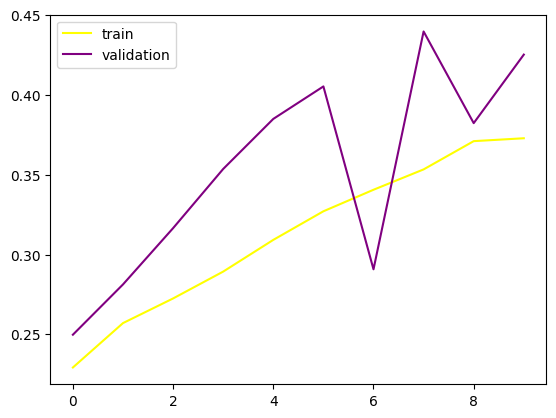

In [ ]:
plt.plot(history.history['accuracy'],color='yellow',label='train')
plt.plot(history.history['val_accuracy'],color='purple',label='validation')
plt.legend()
plt.show()

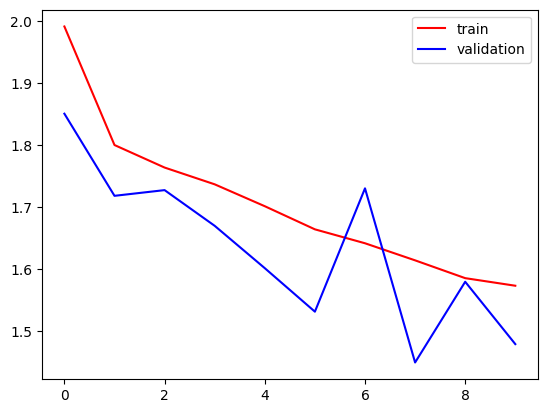

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step


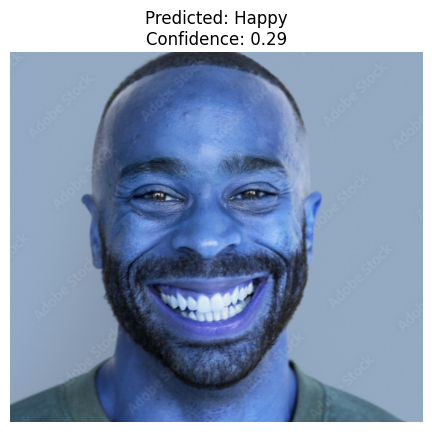

Predicted Emotion: Happy
All Confidence Scores: {'Angry': np.float32(0.14114794), 'Disgust': np.float32(0.023680141), 'Fear': np.float32(0.12861522), 'Happy': np.float32(0.29432482), 'Sad': np.float32(0.16446741), 'Surprise': np.float32(0.16218397), 'Neutral': np.float32(0.08558055)}


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

model.save("emotion_detection.h5")
model = load_model('emotion_detection.h5')

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def predict_emotion(image_path):
    if not cv2.haveImageReader(image_path):
        print(f"Error: Could not read image file: {image_path}")
        return None, None

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # FER-2013 uses 48x48 grayscale

    # Resize to 48x48
    img = cv2.resize(img, (48, 48))

    # Normalize and reshape for model input
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (48,48,1)
    img = np.expand_dims(img, axis=0)    # Add batch dimension (1,48,48,1)

    # Predict emotion
    predictions = model.predict(img)[0]
    predicted_label = emotion_labels[np.argmax(predictions)]

    # Display results
    plt.imshow(cv2.imread(image_path, cv2.IMREAD_COLOR))
    plt.title(f"Predicted: {predicted_label}\nConfidence: {np.max(predictions):.2f}")
    plt.axis('off')
    plt.show()

    return predicted_label, predictions

image_path = "happy.jpg"  # Replace with your image path
predicted_emotion, confidence_scores = predict_emotion(image_path)
print(f"Predicted Emotion: {predicted_emotion}")
print(f"All Confidence Scores: {dict(zip(emotion_labels, confidence_scores))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step


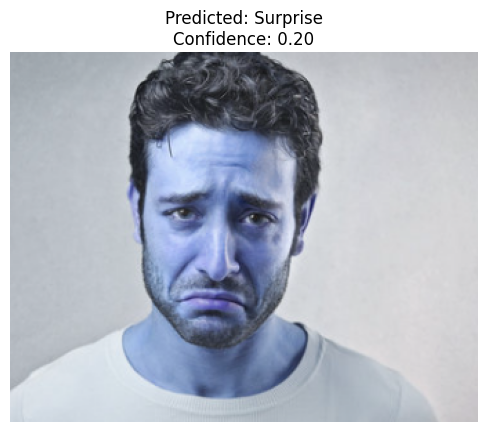

Predicted Emotion: Surprise
All Confidence Scores: {'Angry': np.float32(0.16756316), 'Disgust': np.float32(0.030235602), 'Fear': np.float32(0.15421334), 'Happy': np.float32(0.17817128), 'Sad': np.float32(0.18821563), 'Surprise': np.float32(0.201088), 'Neutral': np.float32(0.08051302)}


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

model.save("emotion_detection.h5")
model = load_model('emotion_detection.h5')

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def predict_emotion(image_path):
    if not cv2.haveImageReader(image_path):
        print(f"Error: Could not read image file: {image_path}")
        return None, None

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # FER-2013 uses 48x48 grayscale

    # Resize to 48x48
    img = cv2.resize(img, (48, 48))

    # Normalize and reshape for model input
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (48,48,1)
    img = np.expand_dims(img, axis=0)    # Add batch dimension (1,48,48,1)

    # Predict emotion
    predictions = model.predict(img)[0]
    predicted_label = emotion_labels[np.argmax(predictions)]

    # Display results
    plt.imshow(cv2.imread(image_path, cv2.IMREAD_COLOR))
    plt.title(f"Predicted: {predicted_label}\nConfidence: {np.max(predictions):.2f}")
    plt.axis('off')
    plt.show()

    return predicted_label, predictions

image_path = "sad.jpg"  # Replace with your image path
predicted_emotion, confidence_scores = predict_emotion(image_path)
print(f"Predicted Emotion: {predicted_emotion}")
print(f"All Confidence Scores: {dict(zip(emotion_labels, confidence_scores))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


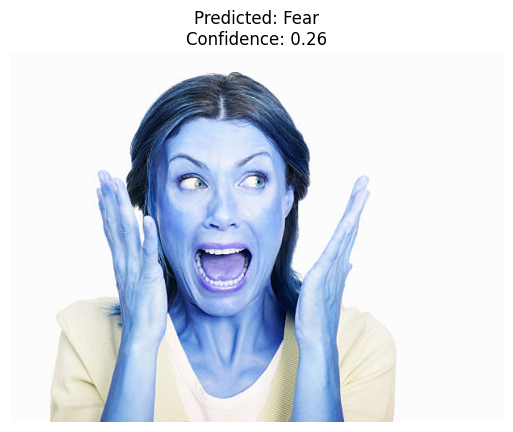

Predicted Emotion: Fear
All Confidence Scores: {'Angry': np.float32(0.11399209), 'Disgust': np.float32(0.023797939), 'Fear': np.float32(0.26083362), 'Happy': np.float32(0.1557335), 'Sad': np.float32(0.106105894), 'Surprise': np.float32(0.09661116), 'Neutral': np.float32(0.24292582)}


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

model.save("emotion_detection.h5")
model = load_model('emotion_detection.h5')

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def predict_emotion(image_path):
    if not cv2.haveImageReader(image_path):
        print(f"Error: Could not read image file: {image_path}")
        return None, None

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # FER-2013 uses 48x48 grayscale

    # Resize to 48x48
    img = cv2.resize(img, (48, 48))

    # Normalize and reshape for model input
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (48,48,1)
    img = np.expand_dims(img, axis=0)    # Add batch dimension (1,48,48,1)

    # Predict emotion
    predictions = model.predict(img)[0]
    predicted_label = emotion_labels[np.argmax(predictions)]

    # Display results
    plt.imshow(cv2.imread(image_path, cv2.IMREAD_COLOR))
    plt.title(f"Predicted: {predicted_label}\nConfidence: {np.max(predictions):.2f}")
    plt.axis('off')
    plt.show()

    return predicted_label, predictions

image_path = "fear.jpg"  # Replace with your image path
predicted_emotion, confidence_scores = predict_emotion(image_path)
print(f"Predicted Emotion: {predicted_emotion}")
print(f"All Confidence Scores: {dict(zip(emotion_labels, confidence_scores))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step


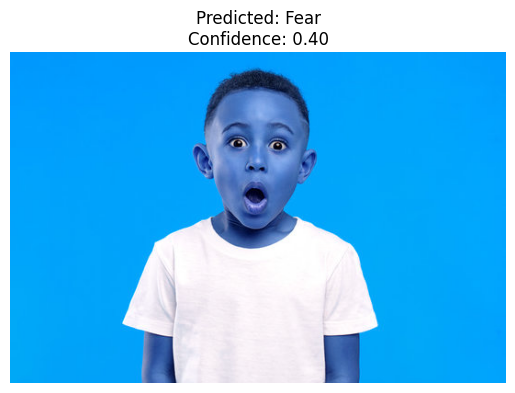

Predicted Emotion: Fear
All Confidence Scores: {'Angry': np.float32(0.10999647), 'Disgust': np.float32(0.020360986), 'Fear': np.float32(0.3967814), 'Happy': np.float32(0.15841816), 'Sad': np.float32(0.0761183), 'Surprise': np.float32(0.07863959), 'Neutral': np.float32(0.15968513)}


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

model.save("emotion_detection.h5")
model = load_model('emotion_detection.h5')

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def predict_emotion(image_path):
    if not cv2.haveImageReader(image_path):
        print(f"Error: Could not read image file: {image_path}")
        return None, None

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # FER-2013 uses 48x48 grayscale

    # Resize to 48x48
    img = cv2.resize(img, (48, 48))

    # Normalize and reshape for model input
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (48,48,1)
    img = np.expand_dims(img, axis=0)    # Add batch dimension (1,48,48,1)

    # Predict emotion
    predictions = model.predict(img)[0]
    predicted_label = emotion_labels[np.argmax(predictions)]

    # Display results
    plt.imshow(cv2.imread(image_path, cv2.IMREAD_COLOR))
    plt.title(f"Predicted: {predicted_label}\nConfidence: {np.max(predictions):.2f}")
    plt.axis('off')
    plt.show()

    return predicted_label, predictions

image_path = "surprise.jpg"  # Replace with your image path
predicted_emotion, confidence_scores = predict_emotion(image_path)
print(f"Predicted Emotion: {predicted_emotion}")
print(f"All Confidence Scores: {dict(zip(emotion_labels, confidence_scores))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step


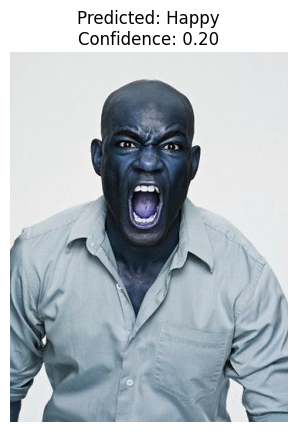

Predicted Emotion: Happy
All Confidence Scores: {'Angry': np.float32(0.15959628), 'Disgust': np.float32(0.027305165), 'Fear': np.float32(0.15050533), 'Happy': np.float32(0.20045337), 'Sad': np.float32(0.17844652), 'Surprise': np.float32(0.1994078), 'Neutral': np.float32(0.084285535)}


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

model.save("emotion_detection.h5")
model = load_model('emotion_detection.h5')

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def predict_emotion(image_path):
    if not cv2.haveImageReader(image_path):
        print(f"Error: Could not read image file: {image_path}")
        return None, None

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # FER-2013 uses 48x48 grayscale

    # Resize to 48x48
    img = cv2.resize(img, (48, 48))

    # Normalize and reshape for model input
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (48,48,1)
    img = np.expand_dims(img, axis=0)    # Add batch dimension (1,48,48,1)

    # Predict emotion
    predictions = model.predict(img)[0]
    predicted_label = emotion_labels[np.argmax(predictions)]

    # Display results
    plt.imshow(cv2.imread(image_path, cv2.IMREAD_COLOR))
    plt.title(f"Predicted: {predicted_label}\nConfidence: {np.max(predictions):.2f}")
    plt.axis('off')
    plt.show()

    return predicted_label, predictions

image_path = "angry.jpg"  # Replace with your image path
predicted_emotion, confidence_scores = predict_emotion(image_path)
print(f"Predicted Emotion: {predicted_emotion}")
print(f"All Confidence Scores: {dict(zip(emotion_labels, confidence_scores))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


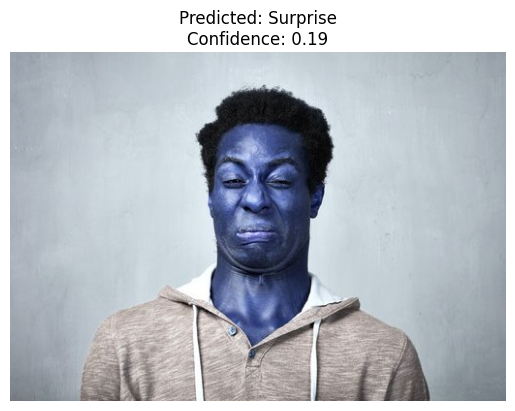

Predicted Emotion: Surprise
All Confidence Scores: {'Angry': np.float32(0.15341714), 'Disgust': np.float32(0.0340876), 'Fear': np.float32(0.18408269), 'Happy': np.float32(0.1809182), 'Sad': np.float32(0.17080258), 'Surprise': np.float32(0.18597057), 'Neutral': np.float32(0.09072124)}


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

model.save("emotion_detection.h5")
model = load_model('emotion_detection.h5')

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def predict_emotion(image_path):
    if not cv2.haveImageReader(image_path):
        print(f"Error: Could not read image file: {image_path}")
        return None, None

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # FER-2013 uses 48x48 grayscale

    # Resize to 48x48
    img = cv2.resize(img, (48, 48))

    # Normalize and reshape for model input
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (48,48,1)
    img = np.expand_dims(img, axis=0)    # Add batch dimension (1,48,48,1)

    # Predict emotion
    predictions = model.predict(img)[0]
    predicted_label = emotion_labels[np.argmax(predictions)]

    # Display results
    plt.imshow(cv2.imread(image_path, cv2.IMREAD_COLOR))
    plt.title(f"Predicted: {predicted_label}\nConfidence: {np.max(predictions):.2f}")
    plt.axis('off')
    plt.show()

    return predicted_label, predictions

image_path = "disgust.jpg"  # Replace with your image path
predicted_emotion, confidence_scores = predict_emotion(image_path)
print(f"Predicted Emotion: {predicted_emotion}")
print(f"All Confidence Scores: {dict(zip(emotion_labels, confidence_scores))}")

In [ ]:
test_img = cv2.imread('/content/happy.jpg')

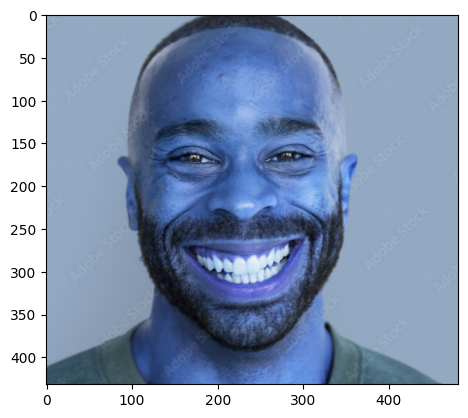

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

(432, 482, 3)

In [ ]:
test_img = cv2.resize(test_img,(48,48))

In [ ]:
test_img = cv2.imread('/content/happy.jpg', cv2.IMREAD_GRAYSCALE)
test_img = cv2.resize(test_img,(48,48))
test_input = test_img.reshape((1, 48, 48, 1))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[4.4641782e-39, 7.0473990e-32, 1.2674249e-13, 2.2079237e-39,
        0.0000000e+00, 0.0000000e+00, 1.0000000e+00]], dtype=float32)